# Environment

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

## Train Dataset Info

In [3]:
train = pd.read_csv("./data/raw/amex_data.csv")

In [4]:
train.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  str    
 1   name                     45528 non-null  str    
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  str    
 4   owns_car                 44981 non-null  str    
 5   owns_house               45528 non-null  str    
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  str    
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)     45528 no

In [6]:
info_train = train.select_dtypes(
    include=["object", "string"]
    ).drop(
        columns=["customer_id", "name"]
        ).apply(
            lambda col: col.unique()
            )

In [7]:
info_train

gender                                                   [F, M, XNA]
owns_car                                                 [N, Y, nan]
owns_house                                                    [Y, N]
occupation_type    [Unknown, Laborers, Core staff, Accountants, H...
dtype: object

In [8]:
info_train["occupation_type"]

<StringArray>
[              'Unknown',              'Laborers',            'Core staff',
           'Accountants', 'High skill tech staff',           'Sales staff',
              'Managers',               'Drivers',        'Medicine staff',
        'Cleaning staff',              'HR staff',        'Security staff',
         'Cooking staff',  'Waiters/barmen staff',    'Low-skill Laborers',
 'Private service staff',           'Secretaries',         'Realty agents',
              'IT staff']
Length: 19, dtype: str

In [9]:
train = train[train["gender"] != "XNA"]

In [10]:
train.drop(columns=["name"], inplace=True)

### Age

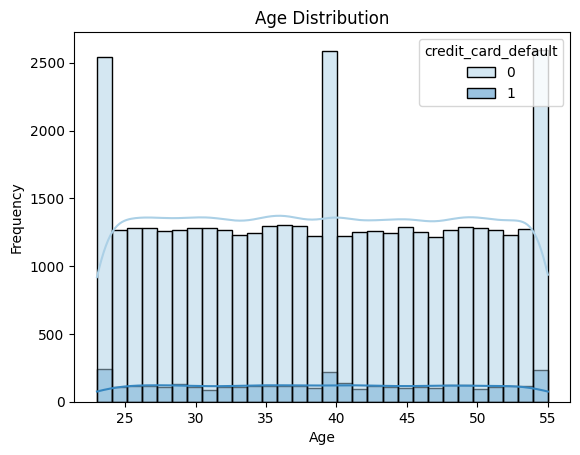

In [11]:
sns.histplot(
    data=train,
    x="age",
    kde=True,
    hue="credit_card_default",
    bins=30,
    palette="Blues"
    )
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

### Gender

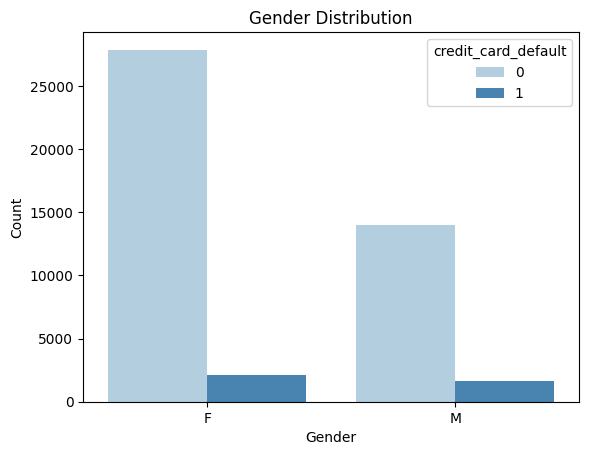

In [12]:
sns.countplot(
    data=train, 
    x="gender", 
    hue="credit_card_default", 
    palette="Blues"
    )
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

### Owns Car

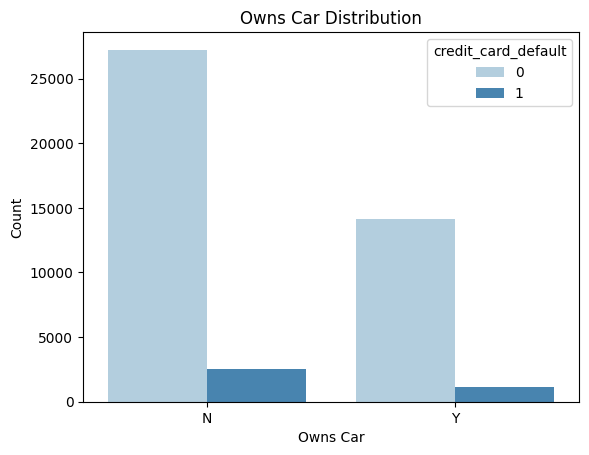

In [13]:
sns.countplot(
    data=train, 
    x="owns_car", 
    hue="credit_card_default", 
    palette="Blues"
    )
plt.xlabel("Owns Car")
plt.ylabel("Count")
plt.title("Owns Car Distribution")
plt.show()

### Owns House

### Credit Card Default

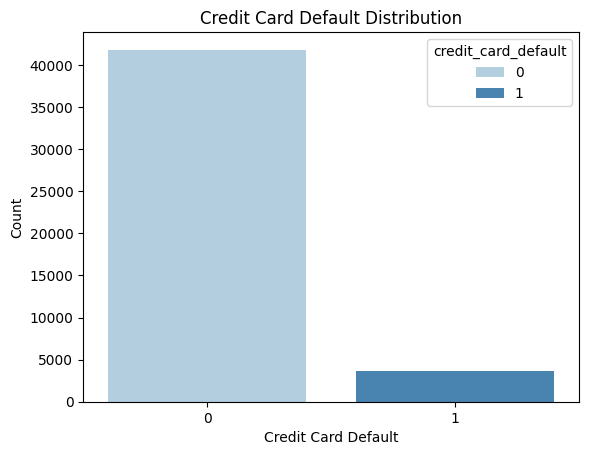

In [14]:
sns.countplot(
    data=train, 
    x="credit_card_default", 
    hue="credit_card_default", 
    palette="Blues"
    )
plt.xlabel("Credit Card Default")
plt.ylabel("Count")
plt.title("Credit Card Default Distribution")
plt.show()

### Number of Children

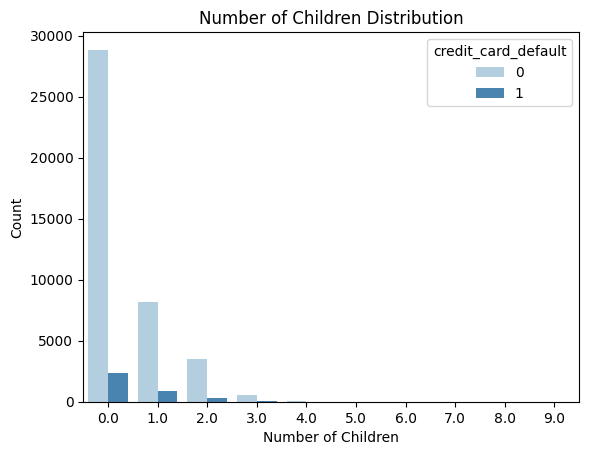

In [15]:
sns.countplot(
    data=train,
    x="no_of_children",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.title("Number of Children Distribution")
plt.show()

### Net Yearly Income

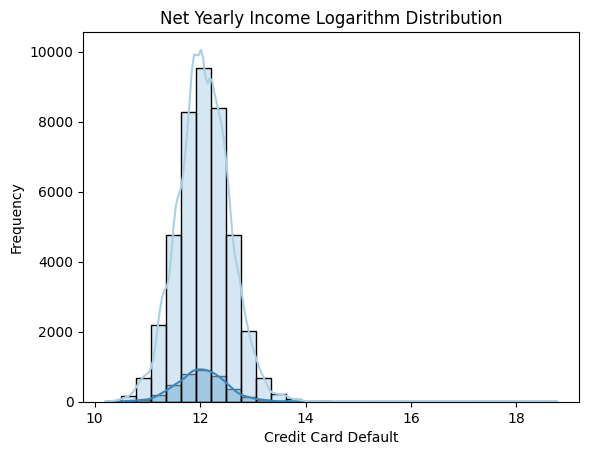

In [16]:
sns.histplot(
    data=train,
    kde=True,
    x=np.log1p(train["net_yearly_income"]),
    hue="credit_card_default",
    bins=30,
    palette="Blues",
    legend=False
)
plt.xlabel("Credit Card Default")
plt.ylabel("Frequency")
plt.title("Net Yearly Income Logarithm Distribution")
plt.show()

### Number of Days Employed

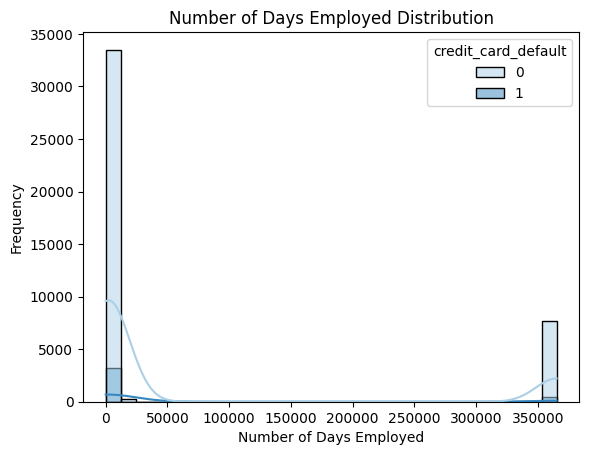

In [17]:
sns.histplot(
    data=train,
    x="no_of_days_employed",
    kde=True,
    hue="credit_card_default",
    bins=30,
    palette="Blues"
    )
plt.xlabel("Number of Days Employed")
plt.ylabel("Frequency")
plt.title("Number of Days Employed Distribution")
plt.show()

### Occupation Type

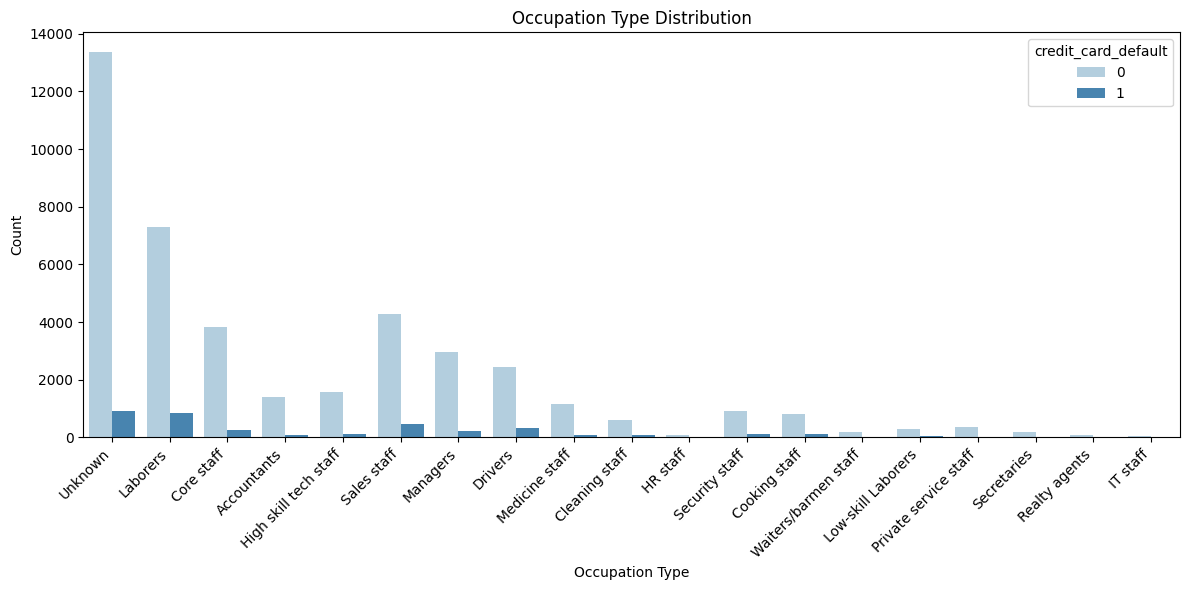

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=train,
    x="occupation_type",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xticks(rotation=45, ha="right")
plt.xlabel("Occupation Type")
plt.ylabel("Count")
plt.title("Occupation Type Distribution")
plt.tight_layout()
plt.show()

### Total Family Members

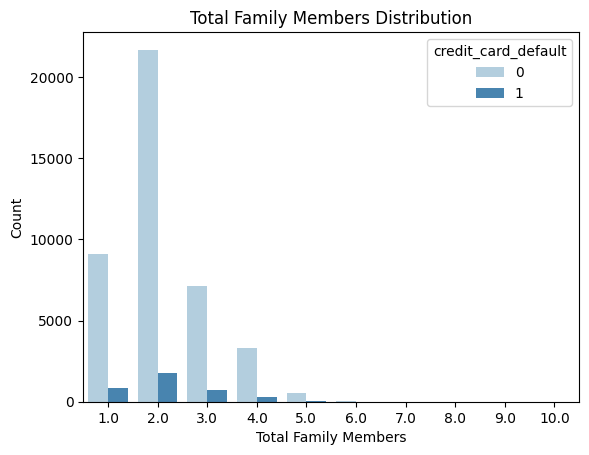

In [19]:
sns.countplot(
    data=train,
    x="total_family_members",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xlabel("Total Family Members")
plt.ylabel("Count")
plt.title("Total Family Members Distribution")
plt.show()

### Migrant Worker

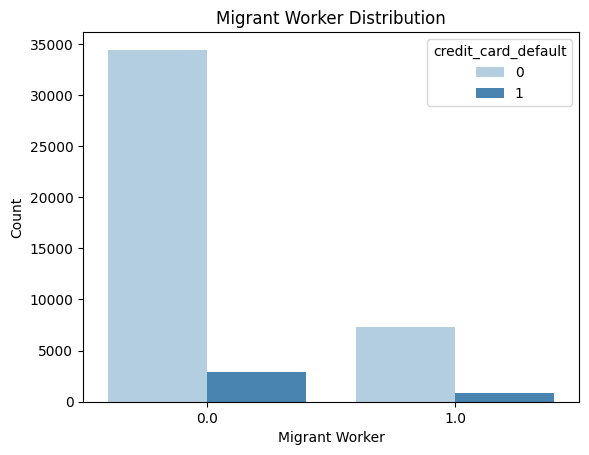

In [20]:
sns.countplot(
    data=train,
    x="migrant_worker",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xlabel("Migrant Worker")
plt.ylabel("Count")
plt.title("Migrant Worker Distribution")
plt.show()

### Yearly Debt Payments

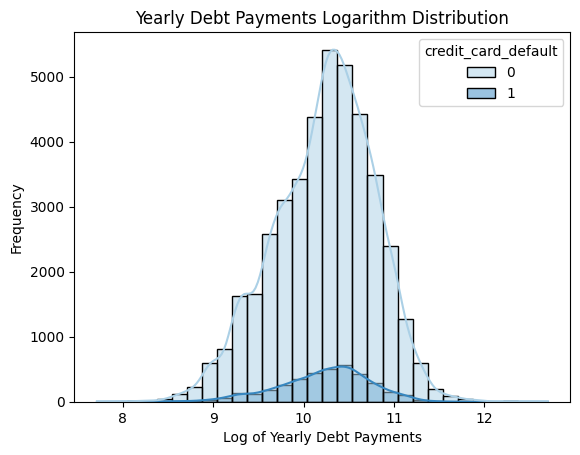

In [21]:
sns.histplot(
    data=train,
    x=np.log1p(train["yearly_debt_payments"]),
    kde=True,
    hue="credit_card_default",
    bins=30,
    palette="Blues"
    )
plt.xlabel("Log of Yearly Debt Payments")
plt.ylabel("Frequency")
plt.title("Yearly Debt Payments Logarithm Distribution")
plt.show()

### Credit Limit

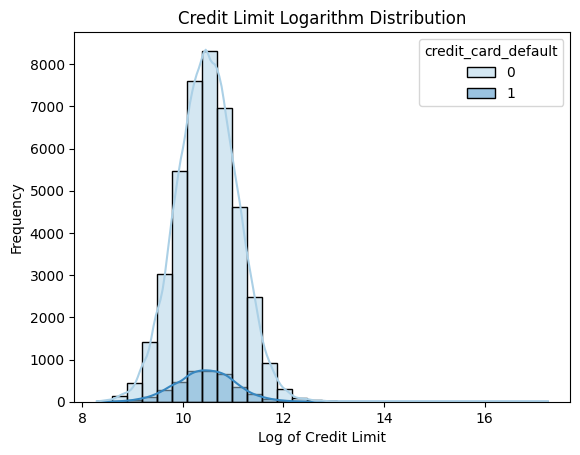

In [22]:
sns.histplot(
    data=train,
    kde=True,
    x=np.log1p(train["credit_limit"]),
    hue="credit_card_default",
    bins=30,
    palette="Blues",
)
plt.xlabel("Log of Credit Limit")
plt.ylabel("Frequency")
plt.title("Credit Limit Logarithm Distribution")
plt.show()

### Credit Limit Used (%)

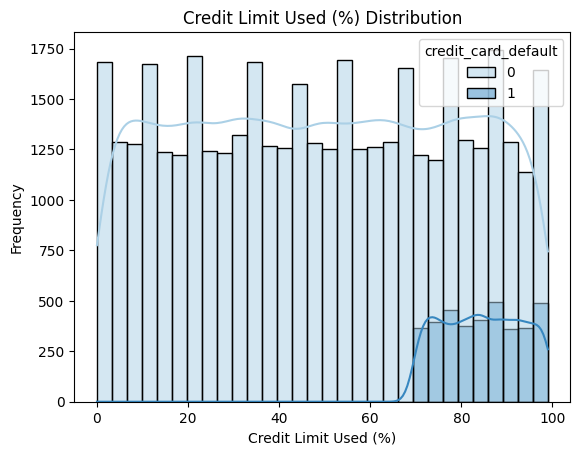

In [23]:
sns.histplot(
    data=train,
    x="credit_limit_used(%)",
    kde=True,
    hue="credit_card_default",
    bins=30,
    palette="Blues"
    )
plt.xlabel("Credit Limit Used (%)")
plt.ylabel("Frequency")
plt.title("Credit Limit Used (%) Distribution")
plt.show()

### Credit Score

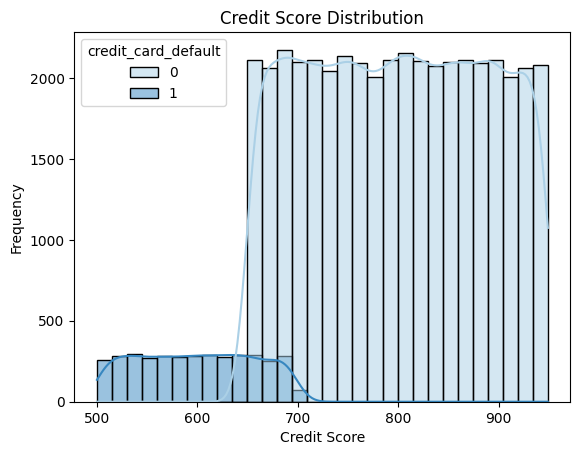

In [24]:
sns.histplot(
    data=train,
    x="credit_score",
    kde=True,
    hue="credit_card_default",
    bins=30,
    palette="Blues"
    )
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Credit Score Distribution")
plt.show()

### Previous Defaults

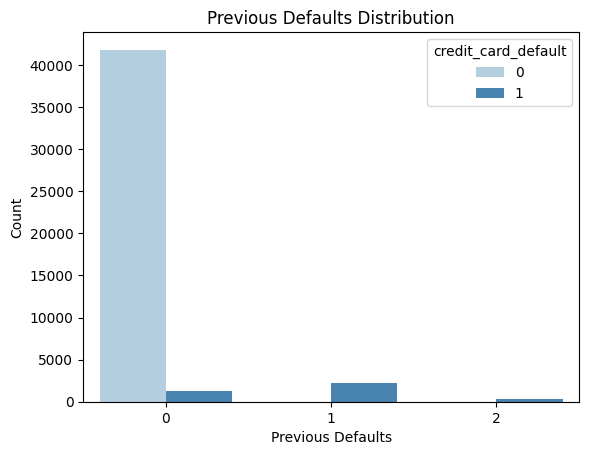

In [25]:
sns.countplot(
    data=train,
    x="prev_defaults",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xlabel("Previous Defaults")
plt.ylabel("Count")
plt.title("Previous Defaults Distribution")
plt.show()

### Default in Last 6 Months

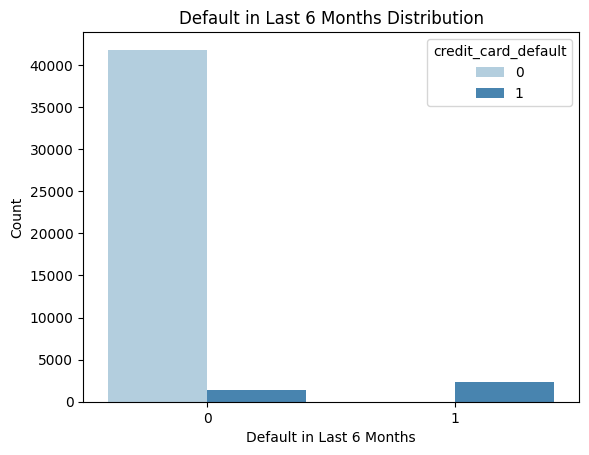

In [26]:
sns.countplot(
    data=train,
    x="default_in_last_6months",
    hue="credit_card_default",
    palette="Blues"
    )
plt.xlabel("Default in Last 6 Months")
plt.ylabel("Count")
plt.title("Default in Last 6 Months Distribution")
plt.show()